In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(style='ticks')
from sklearn import metrics
import plotly
import plotly.plotly as py
import plotly.graph_objs as go
import cufflinks as cf
plotly.tools.set_credentials_file(username='ugurgudelek', api_key='yKoQicaYh2RoqEoNI99C')

In [27]:
buy_sell_df = pd.read_pickle("../result/buy_sell_model_regr_2017_07_13 19_09_09_221944")
shares_df = pd.read_pickle("../result/buy_sell_model_regr_shares_2017_07_13 19_02_45_271761")
shares_df['Dates'] = buy_sell_df['Dates']

In [28]:
pred = pd.read_pickle("../result/predictions_model_regr_100epoch_2017_07_11 16_24_27_177432")
pred['disc_label'] = pred.Actual.apply(lambda x: int((x+1)*(1.5)))
pred['disc_pred'] = pred.Prediction.apply(lambda x: int((x+1)*(1.5)))
pred['disc_pred'].loc[pred['disc_pred'] > 2] = 2
pred['index']=np.array(pred.index+1, dtype='int64')

c:\program files\python35\lib\site-packages\pandas\core\indexing.py:179: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy



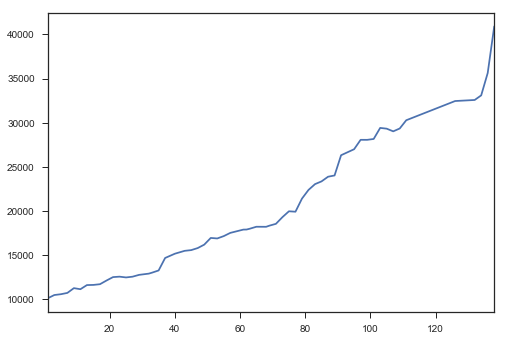

In [29]:
buy_sell_df[buy_sell_df['Capitals']> 10000]['Capitals'].plot()


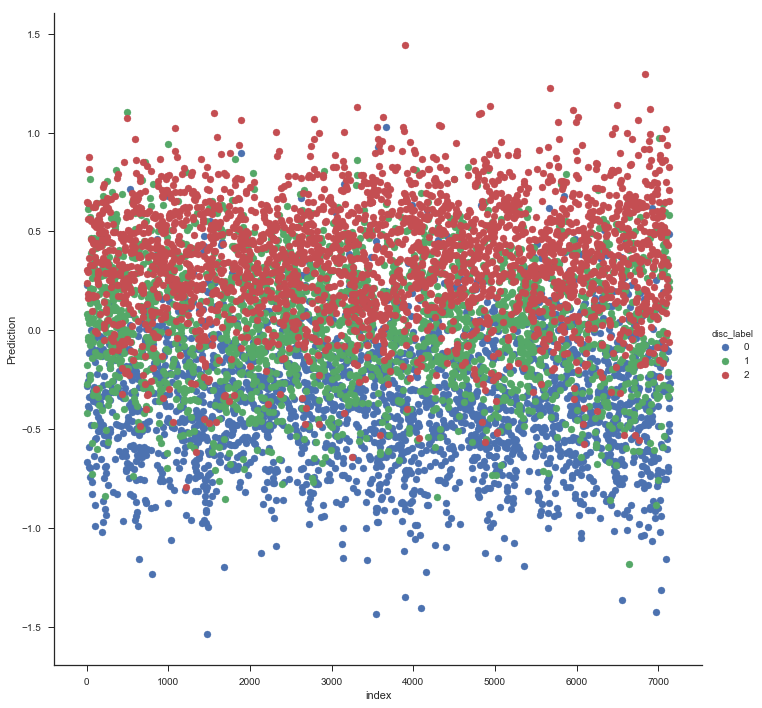

In [30]:
fg = sns.FacetGrid(data=pred, hue='disc_label',aspect=1, size =10)
fg.map(plt.scatter, 'index','Prediction', alpha=1).add_legend()

In [31]:
cf1 = metrics.confusion_matrix(y_pred=pred.disc_pred, y_true=pred.disc_label)
acc = np.sum(np.sum(np.diag(cf1)))/np.sum(np.sum(cf1))
acc

0.60498669281411965

In [32]:
pred_exp_hold = pred.copy()
pred_exp_hold = pred_exp_hold.loc[np.logical_or((pred_exp_hold.Prediction > 0.38),(pred_exp_hold.Prediction < -0.38)) ]
pred_exp_hold['disc_label'] =  pred_exp_hold.Actual.apply(lambda x: int(x+1))
pred_exp_hold['disc_pred'] =  pred_exp_hold.Prediction.apply(lambda x: int(x+1))
pred_exp_hold['disc_pred'].loc[pred_exp_hold['disc_pred'] > 1] = 1
pred_exp_hold['disc_index'] = pred_exp_hold.index


c:\program files\python35\lib\site-packages\pandas\core\indexing.py:179: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy



In [33]:
pred_exp_hold.head()

,Actual,Date,Name,Prediction,disc_label,disc_pred,index,disc_index
0,-0.898692,2015-03-24,spy,-0.666527,0,0,1,0
7,0.587159,2015-04-02,spy,0.649337,1,1,8,7
8,-0.258630,2015-04-06,spy,-0.421796,0,0,9,8
10,0.415591,2015-04-08,spy,0.560521,1,1,11,10
12,-0.423784,2015-04-10,spy,-0.383139,0,0,13,12


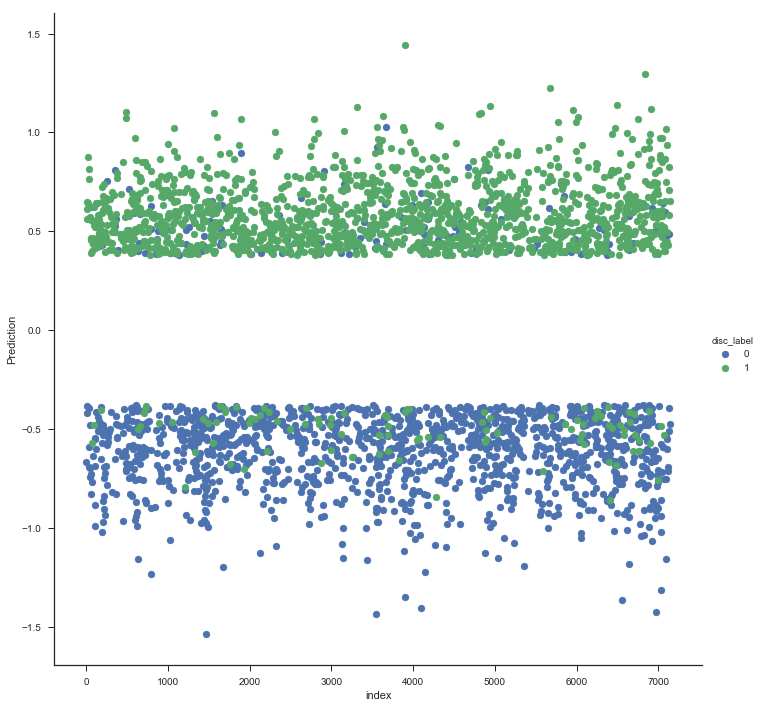

In [34]:
fg = sns.FacetGrid(data=pred_exp_hold, hue='disc_label',aspect=1, size =10)
fg.map(plt.scatter, 'index','Prediction', alpha=1).add_legend()

In [35]:
cf2 = metrics.confusion_matrix(y_pred=pred_exp_hold.disc_pred, y_true=pred_exp_hold.disc_label)
acc = np.sum(np.sum(np.diag(cf2)))/np.sum(np.sum(cf2))
acc


0.92154255319148937

In [36]:
pred_exp_hold.disc_pred.unique()

array([0, 1], dtype=int64)

In [37]:
buy_over_50 = buy_sell_df.loc[buy_sell_df.Amounts > 50]
buy_over_50 = buy_over_50.loc[buy_over_50.Operations == 'buy']
buy_over_50['total_capital'] = buy_over_50.Prices * buy_over_50.Amounts +  buy_over_50.Capitals
buy_over_50

,Amounts,Capitals,Dates,Names,Operations,Prices,Transaction Costs,total_capital
0,56.0,88.64,2015-03-27,dia,buy,176.81,10,9990.00
2,174.0,29.44,2015-03-31,eww,buy,57.96,10,10114.48
6,140.0,11.04,2015-05-06,xly,buy,75.40,10,10567.04
8,475.0,18.04,2015-05-11,ewa,buy,22.52,10,10715.04
10,212.0,19.54,2015-05-18,ewj,buy,53.00,10,11255.54
12,388.0,21.46,2015-06-09,ewg,buy,28.64,10,11133.78
14,153.0,0.67,2015-06-25,xle,buy,75.83,10,11602.66
16,476.0,16.03,2015-06-30,xlf,buy,24.38,10,11620.91
18,543.0,20.94,2015-07-09,ewh,buy,21.51,10,11700.87
20,238.0,24.87,2015-07-27,ewj,buy,50.80,10,12115.27


In [38]:
sell_over_50 = buy_sell_df.loc[buy_sell_df.Operations == 'sell']
sell_over_50 = sell_over_50.loc[sell_over_50.Amounts > 50]
sell_over_50

,Amounts,Capitals,Dates,Names,Operations,Prices,Transaction Costs
1,56.0,10124.48,2015-03-30,dia,sell,179.39,10
3,174.0,10485.54,2015-04-09,eww,sell,60.15,10
7,140.0,10725.04,2015-05-08,xly,sell,76.60,10
9,475.0,11265.54,2015-05-15,ewa,sell,23.70,10
11,212.0,11143.78,2015-06-03,ewj,sell,52.52,10
13,388.0,11612.66,2015-06-23,ewg,sell,29.90,10
15,153.0,11630.91,2015-06-26,xle,sell,76.08,10
17,476.0,11710.87,2015-07-07,xlf,sell,24.59,10
19,543.0,12125.27,2015-07-24,ewh,sell,22.31,10
21,238.0,12514.63,2015-08-10,ewj,sell,52.52,10


In [39]:
pred.head()

,Actual,Date,Name,Prediction,disc_label,disc_pred,index
0,-0.898692,2015-03-24,spy,-0.666527,0,0,1
1,-0.233740,2015-03-25,spy,0.083561,1,1,2
2,0.225048,2015-03-26,spy,-0.177466,1,1,3
3,0.839650,2015-03-27,spy,0.302598,2,1,4
4,-0.703375,2015-03-30,spy,-0.282021,0,1,5


In [40]:
def list_of_df_to_df(list_of_df):
    df = pd.DataFrame()
    col_names = list_of_df[0].columns
    for col in col_names:
        df[col] = [row[col].values[0] for row in list_of_df]
    return df

In [41]:
buy_operations = buy_sell_df[buy_sell_df.Operations == 'buy']
sell_operations = buy_sell_df[buy_sell_df.Operations == 'sell']

buy_operations_pred = list_of_df_to_df([pred[np.logical_and((pred.Date == date),(pred.Name == name))]
                       for date,name in zip(buy_operations['Dates'], buy_operations['Names'])])
buy_operations_pred['Dates'] = buy_operations_pred['Date']
buy_operations_pred.drop('Date',axis=1)
buy_operations_huge = pd.merge(left=buy_operations, right=buy_operations_pred ,on='Dates')

sell_operations_pred = list_of_df_to_df([pred[np.logical_and((pred.Date == date),(pred.Name == name))]
                       for date,name in zip(sell_operations['Dates'], sell_operations['Names'])])
sell_operations_pred['Dates'] = sell_operations_pred['Date']
sell_operations_pred.drop('Date',axis=1)
sell_operations_huge = pd.merge(left=sell_operations, right=sell_operations_pred ,on='Dates')

sell_operations_huge



,Amounts,Capitals,Dates,Names,Operations,Prices,Transaction Costs,Actual,Date,Name,Prediction,disc_label,disc_pred,index
0,56.0,10124.48,2015-03-30,dia,sell,179.39,10,-0.765338,2015-03-30,dia,-0.505601,0,0,5044
1,174.0,10485.54,2015-04-09,eww,sell,60.15,10,-0.581684,2015-04-09,eww,-0.471765,0,0,4632
2,50.0,10577.04,2015-05-04,spy,sell,211.32,10,-0.816152,2015-05-04,spy,-0.589373,0,0,29
3,140.0,10725.04,2015-05-08,xly,sell,76.60,10,-0.416842,2015-05-08,xly,-0.502472,0,0,4233
4,475.0,11265.54,2015-05-15,ewa,sell,23.70,10,-0.962816,2015-05-15,ewa,-0.564092,0,0,6757
5,212.0,11143.78,2015-06-03,ewj,sell,52.52,10,-0.595053,2015-06-03,ewj,-0.515937,0,0,3410
6,388.0,11612.66,2015-06-23,ewg,sell,29.90,10,-0.813443,2015-06-23,ewg,-0.821989,0,0,5523
7,153.0,11630.91,2015-06-26,xle,sell,76.08,10,-0.955612,2015-06-26,xle,-0.692866,0,0,1327
8,476.0,11710.87,2015-07-07,xlf,sell,24.59,10,-0.941225,2015-07-07,xlf,-0.674383,0,0,493
9,543.0,12125.27,2015-07-24,ewh,sell,22.31,10,-0.990815,2015-07-24,ewh,-0.630573,0,0,5965


In [42]:
buy_type = [[],[],[]],[[],[],[]],[[],[],[]]
for i in [0,1,2]:
    for j in [0,1,2]:
        buy_type[i][j] = buy_operations_huge[np.logical_and((buy_operations_huge.disc_label == i),(buy_operations_huge.disc_pred == j))]
sell_type = [[],[],[]],[[],[],[]],[[],[],[]]
for i in [0,1,2]:
    for j in [0,1,2]:
        sell_type[i][j] = sell_operations_huge[np.logical_and((sell_operations_huge.disc_label == i),(sell_operations_huge.disc_pred == j))]

In [43]:
buy_signal = [{'x': buy_type[i][j]['Date'],
              'y': buy_type[i][j]['Prediction'],
              'name': 'buy_'+str(i)+str(j),
              'mode': 'markers',
               'marker' : dict(
                            size = 10,
                            line = dict(
                                width = 2,
                            )
                        )
              } for i in [0,1,2] for j in [0,1,2] ]

sell_signal = [{'x': sell_type[i][j]['Date'],
              'y': sell_type[i][j]['Prediction'],
              'name': 'sell_'+str(i)+str(j),
              'mode': 'markers',
               'marker' : dict(
                            size = 10,
                            line = dict(
                                width = 2,
                            )
                        )
              } for i in [0,1,2] for j in [0,1,2] ]

predictions_dist = [{'x': pred[pred.disc_label == disc_label]['Date'],
                          'y': pred[pred.disc_label == disc_label]['Prediction'],
                          'name': disc_label,
                          'mode': 'markers'
                          }for disc_label in [0,1,2]
                       ]




py.iplot(
    {
        'data': predictions_dist + buy_signal + sell_signal,
        'layout': {
            'xaxis': {'title': 'Date', 'type': 'lin'},
            'yaxis': {'title': "Predictions"}
        }
    })

|  (Buy)      |                  |                |   **Predictions**  |                ||     *      ||  (Sell)      |                  |                |   **Predictions**  |                |
|-------------|------------------|----------------|--------------------|----------------||-||-------------|------------------|----------------|--------------------|----------------|
|             |                  |<u>**Sell**</u> | <u>**Hold**</u>    | <u>**Buy**</u> ||     *      ||             |                  |<u>**Sell**</u> | <u>**Hold**</u>    | <u>**Buy**</u> |
|             |<u>**Sell**</u>   |buy_00          |buy_01              |buy_02          ||     *      ||             |<u>**Sell**</u>   |sell_00          |sell_01              |sell_02          |
|**Actuals**  |<u>**Hold**</u>   |buy_10          |buy_11              |buy_12          ||     *      ||**Actuals**  |<u>**Hold**</u>   |sell_10          |sell_11              |sell_12          |
|             |<u>**Buy**</u>    |buy_20          |buy_21              |buy_22          ||     *      ||             |<u>**Buy**</u>    |sell_20          |sell_21              |sell_22          |






In [44]:
buy_type[1][2]

,Amounts,Capitals,Dates,Names,Operations,Prices,Transaction Costs,Actual,Date,Name,Prediction,disc_label,disc_pred,index
2,50.0,21.04,2015-04-13,spy,buy,209.09,10,0.189005,2015-04-13,spy,0.612748,1,2,14
5,212.0,19.54,2015-05-18,ewj,buy,53.00,10,0.075329,2015-05-18,ewj,0.501172,1,2,3399
7,153.0,0.67,2015-06-25,xle,buy,75.83,10,0.318238,2015-06-25,xle,0.541521,1,2,1326
11,166.0,6.49,2015-08-11,xlv,buy,75.29,10,0.066312,2015-08-11,xlv,0.689493,1,2,2618
17,310.0,30.68,2015-09-22,xlu,buy,41.87,10,0.256836,2015-09-22,xlu,0.412693,1,2,967
33,94.0,167.99,2016-01-08,spy,buy,191.92,10,0.098677,2016-01-08,spy,0.676731,1,2,202
38,977.0,10.62,2016-02-08,xlf,buy,20.42,10,-0.145867,2016-02-08,xlf,0.438121,1,2,642
42,517.0,3.74,2016-03-23,xlb,buy,44.55,10,0.000000,2016-03-23,xlb,0.807971,1,2,4033
49,555.0,17.16,2016-05-26,eww,buy,50.52,10,0.059313,2016-05-26,eww,0.524128,1,2,4918
50,1181.0,3.66,2016-05-31,xlf,buy,23.75,10,0.207470,2016-05-31,xlf,0.851572,1,2,720


In [45]:
buy_sell_df.loc[buy_sell_df.Operations == 'buy'].shape

(70, 7)

In [46]:
buy_sell_df.loc[buy_sell_df.Operations == 'sell'].shape

(69, 7)

In [47]:
buy_sell_df

,Amounts,Capitals,Dates,Names,Operations,Prices,Transaction Costs
0,56.0,88.64,2015-03-27,dia,buy,176.81,10
1,56.0,10124.48,2015-03-30,dia,sell,179.39,10
2,174.0,29.44,2015-03-31,eww,buy,57.96,10
3,174.0,10485.54,2015-04-09,eww,sell,60.15,10
4,50.0,21.04,2015-04-13,spy,buy,209.09,10
5,50.0,10577.04,2015-05-04,spy,sell,211.32,10
6,140.0,11.04,2015-05-06,xly,buy,75.40,10
7,140.0,10725.04,2015-05-08,xly,sell,76.60,10
8,475.0,18.04,2015-05-11,ewa,buy,22.52,10
9,475.0,11265.54,2015-05-15,ewa,sell,23.70,10


In [48]:
shares_df

,dia,ewa,ewc,ewg,ewh,ewj,eww,spy,xlb,xle,xlf,xli,xlk,xlp,xlu,xlv,xly,Dates
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,131.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-03-27
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-03-30
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,182.0,0.0,0.0,0.0,0.0,0.0,2015-03-31
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-04-09
4,0.0,0.0,0.0,0.0,0.0,0.0,177.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-04-13
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-05-04
6,0.0,462.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-05-06
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-05-08
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,447.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-05-11
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-05-15
